In [1]:
import pandas as pd
import numpy as np
import ast
import warnings
warnings.filterwarnings('ignore')

import gensim
import gensim.corpora as corpora
from gensim.models import CoherenceModel, LdaModel
import pyLDAvis
import pyLDAvis.gensim_models
import matplotlib.pyplot as plt
import pickle
import os

os.makedirs('result_LDA_news', exist_ok=True)
print("Gensim version:", gensim.__version__)

Gensim version: 4.3.1


In [2]:
df = pd.read_csv('data/LDA_news.csv')
df['tokens'] = df['stemmed'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df = df[df['tokens'].apply(len) > 0].reset_index(drop=True)
print(f"Jumlah dokumen setelah filter: {len(df)}")
print("Contoh token dokumen pertama:", df['tokens'].iloc[0])

Jumlah dokumen setelah filter: 234
Contoh token dokumen pertama: ['korps', 'berantas', 'tindak', 'pidana', 'korupsi', 'kortas', 'tindak', 'pidana', 'korupsi', 'polisi', 'republik', 'indonesia', 'ungkap', 'duga', 'korupsi', 'direktorat', 'jenderal', 'energi', 'baru', 'konservasi', 'energi', 'energi', 'baru', 'konservasi', 'energi', 'menteri', 'energi', 'sumber', 'daya', 'mineral', 'kait', 'pengadaan', 'terang', 'jalan', 'tenaga', 'surya', 'terang', 'jalan', 'tenaga', 'surya', 'polisi', 'republik', 'indonesia', 'sebut', 'kerugian', 'dirtindak', 'kortastipidkor', 'brigjen', 'totok', 'suharyanto', 'orang', 'tetap', 'tersangka', 'tiga', 'tersangka', 'mantan', 'inspektur', 'jenderal', 'menteri', 'energi', 'sumber', 'daya', 'mineral', 'periode', 'mantan', 'sekretaris', 'direktorat', 'jenderal', 'energi', 'baru', 'konservasi', 'energi', 'kuasa', 'guna', 'anggar', 'mantan', 'direktur', 'operasional', 'persero', 'batas', 'len', 'industri', 'totok', 'direktorat', 'jenderal', 'energi', 'baru', 'ko

In [3]:
id2word = corpora.Dictionary(df['tokens'])
id2word.filter_extremes(no_below=2, no_above=0.7)

corpus = [id2word.doc2bow(text) for text in df['tokens']]
print("Ukuran dictionary setelah filter:", len(id2word))
print("Jumlah dokumen dalam corpus:", len(corpus))

Ukuran dictionary setelah filter: 2673
Jumlah dokumen dalam corpus: 234


In [4]:
min_topics = 2
max_topics = 15
step = 1
topic_range = range(min_topics, max_topics + 1, step)

coherence_cv = []

for num_topics in topic_range:
    print(f"Melatih model dengan {num_topics} topik....")

    lda_model = gensim.models.LdaModel(
        corpus=corpus,
        id2word=id2word,
        num_topics=num_topics,
        random_state=42,
        passes=5,  # sengaja rendah untuk efisiensi loop, model final pakai passes=50
        alpha='auto',
        per_word_topics=False
    )

    coh_cv = CoherenceModel(
        model=lda_model,
        texts=df['tokens'],
        dictionary=id2word,
        coherence='c_v'
    ).get_coherence()
    coherence_cv.append(coh_cv)

    print(f"c_v = {coh_cv:.4f}")

Melatih model dengan 2 topik....
c_v = 0.4781
Melatih model dengan 3 topik....
c_v = 0.5405
Melatih model dengan 4 topik....
c_v = 0.4929
Melatih model dengan 5 topik....
c_v = 0.4901
Melatih model dengan 6 topik....
c_v = 0.4741
Melatih model dengan 7 topik....
c_v = 0.4470
Melatih model dengan 8 topik....
c_v = 0.4715
Melatih model dengan 9 topik....
c_v = 0.4613
Melatih model dengan 10 topik....
c_v = 0.4512
Melatih model dengan 11 topik....
c_v = 0.4122
Melatih model dengan 12 topik....
c_v = 0.4645
Melatih model dengan 13 topik....
c_v = 0.5021
Melatih model dengan 14 topik....
c_v = 0.4487
Melatih model dengan 15 topik....
c_v = 0.4913


c:\skripsi\model\LDA_skripsi\lda_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\skripsi\model\LDA_skripsi\lda_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\skripsi\model\LDA_skripsi\lda_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


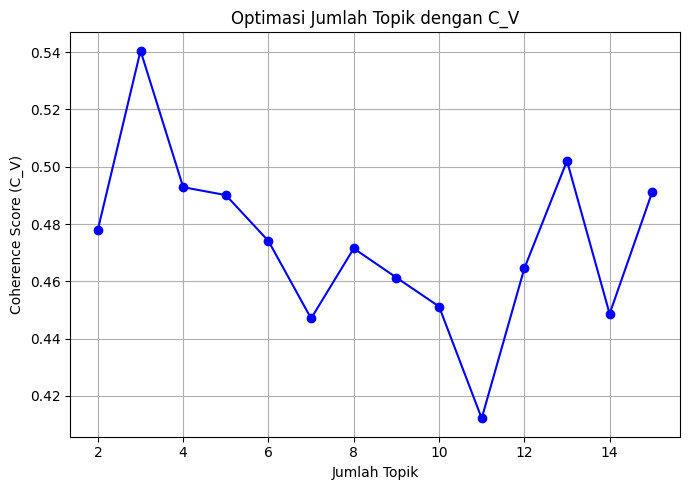

Topik 2: c_v=0.4781
Topik 3: c_v=0.5405
Topik 4: c_v=0.4929
Topik 5: c_v=0.4901
Topik 6: c_v=0.4741
Topik 7: c_v=0.4470
Topik 8: c_v=0.4715
Topik 9: c_v=0.4613
Topik 10: c_v=0.4512
Topik 11: c_v=0.4122
Topik 12: c_v=0.4645
Topik 13: c_v=0.5021
Topik 14: c_v=0.4487
Topik 15: c_v=0.4913

Jumlah topik optimal berdasarkan c_v tertinggi: 3


In [5]:
plt.figure(figsize=(7, 5))
plt.plot(topic_range, coherence_cv, marker='o', color='b')
plt.xlabel('Jumlah Topik')
plt.ylabel('Coherence Score (C_V)')
plt.title('Optimasi Jumlah Topik dengan C_V')
plt.grid(True)
plt.tight_layout()
plt.savefig('result_LDA_news/coherence_optimization.png', dpi=150)
plt.show()

for t, cv in zip(topic_range, coherence_cv):
    print(f"Topik {t}: c_v={cv:.4f}")

optimal_topics = topic_range[np.argmax(coherence_cv)]
print(f"\nJumlah topik optimal berdasarkan c_v tertinggi: {optimal_topics}")

In [6]:
num_topics_final = optimal_topics
passes_final = 50

print(f"Melatih model final dengan {num_topics_final} topik, passes={passes_final}...")
lda_final = gensim.models.LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=num_topics_final,
    random_state=42,
    passes=passes_final,
    alpha='auto',
    per_word_topics=True
)

coh_final = CoherenceModel(
    model=lda_final,
    texts=df['tokens'].tolist(),
    dictionary=id2word,
    coherence='c_v'
).get_coherence()
print(f"Coherence Score Final (c_v): {coh_final:.4f}")

def topic_diversity(lda_model, topn=25):
    topics = [lda_model.show_topic(i, topn=topn) for i in range(lda_model.num_topics)]
    all_words = [word for topic in topics for word, _ in topic]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words)

td_score = topic_diversity(lda_final, topn=25)
print(f"Topic Diversity: {td_score:.4f}")

Melatih model final dengan 3 topik, passes=50...
Coherence Score Final (c_v): 0.5644
Topic Diversity: 0.7867


In [7]:
print("Topik-topik yang ditemukan:")
for idx, topic in lda_final.print_topics(num_words=10):
    print(f"Topik {idx}: {topic}")

def get_topic_keywords(lda_model, topic_id, num_words=5):
    words = lda_model.show_topic(topic_id, topn=num_words)
    return [word for word, prob in words]

print()
print("=================================================================\n")

topic_labels = {}
for i in range(num_topics_final):
    keywords = get_topic_keywords(lda_final, i
                                  , 5)
    label = ' + '.join(keywords)
    topic_labels[i] = label
    print(f"Topik {i}: {label}")

Topik-topik yang ditemukan:
Topik 0: 0.025*"energi" + 0.013*"indonesia" + 0.011*"sumber" + 0.010*"bbm" + 0.010*"daya" + 0.010*"campur" + 0.010*"bahlil" + 0.009*"hasil" + 0.009*"perintah" + 0.008*"sawit"
Topik 1: 0.014*"motor" + 0.011*"pertalite" + 0.009*"kandung" + 0.008*"air" + 0.008*"mesin" + 0.007*"suzuki" + 0.007*"milik" + 0.007*"campur" + 0.006*"kendara" + 0.006*"spbu"
Topik 2: 0.040*"pertamina" + 0.035*"bbm" + 0.023*"spbu" + 0.016*"swasta" + 0.014*"beli" + 0.014*"kandung" + 0.013*"shell" + 0.012*"fuel" + 0.011*"base" + 0.010*"energi"


Topik 0: energi + indonesia + sumber + bbm + daya
Topik 1: motor + pertalite + kandung + air + mesin
Topik 2: pertamina + bbm + spbu + swasta + beli


In [8]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_final, corpus, id2word)
pyLDAvis.save_html(vis, 'result_LDA_news/lda_visualization.html')
print("Visualisasi disimpan sebagai 'lda_visualization.html'")

Visualisasi disimpan sebagai 'lda_visualization.html'


   id  dominant_topic  topic_prob
0   1               2    0.646340
1   2               1    0.999224
2   3               1    0.999004
3   4               0    0.999675
4   5               0    0.999683
5   6               0    0.999590
6   7               0    0.999530
7   8               0    0.995970
8   9               2    0.999154
9  10               0    0.751110


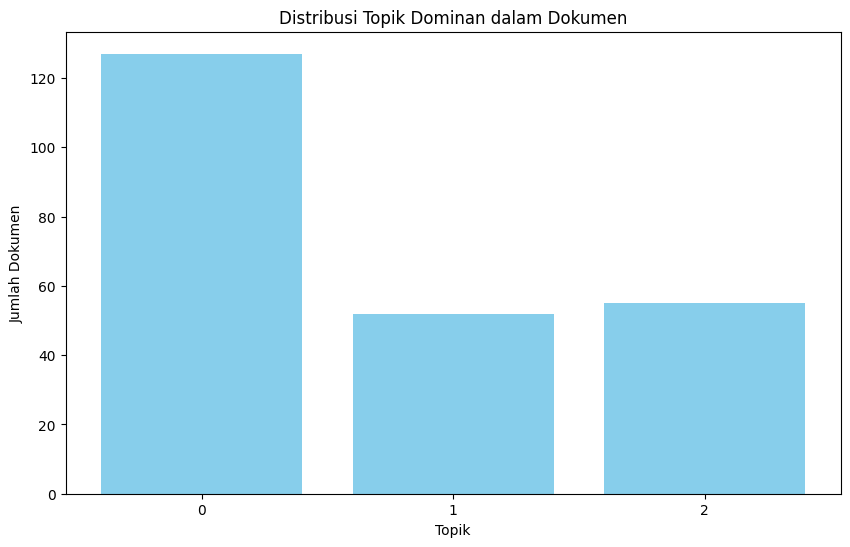

In [9]:
def get_dominant_topic(lda_model, corpus):
    dominant_topics = []
    topic_probs = []
    for doc_bow in corpus:
        doc_topics = lda_model.get_document_topics(doc_bow)
        dominant = max(doc_topics, key=lambda x: x[1])
        dominant_topics.append(dominant[0])
        topic_probs.append(dominant[1])
    return dominant_topics, topic_probs

dominant_topics, topic_probs = get_dominant_topic(lda_final, corpus)

df['dominant_topic'] = dominant_topics
df['topic_prob'] = topic_probs

print(df[['id', 'dominant_topic', 'topic_prob']].head(10))

df.to_csv('result_LDA_news/documents_with_topics.csv', index=False)

plt.figure(figsize=(10, 6))
topic_counts = df['dominant_topic'].value_counts().sort_index()
plt.bar(topic_counts.index, topic_counts.values, color='skyblue')
plt.xlabel('Topik')
plt.ylabel('Jumlah Dokumen')
plt.title('Distribusi Topik Dominan dalam Dokumen')
plt.xticks(range(num_topics_final))
plt.savefig('result_LDA_news/topic_distribution.png', dpi=150)
plt.show()

In [10]:
lda_final.save('result_LDA_news/lda_model_final.model')
id2word.save('result_LDA_news/dictionary.dict')

with open('result_LDA_news/corpus.pkl', 'wb') as f:
    pickle.dump(corpus, f)

with open('result_LDA_news/topic_labels.pkl', 'wb') as f:
    pickle.dump(topic_labels, f)

print("Model, dictionary, corpus, dan topic labels berhasil disimpan.")

Model, dictionary, corpus, dan topic labels berhasil disimpan.
